# Traditional Classifier: Linear SVM vs Random Forest

This notebook implements the traditional (handcrafted-feature) classification
pipeline for the project. Two classical classifiers — a Linear SVM and a Random
Forest — are trained on combined HOG + RGB colour histogram features and
compared against a trivial nearest-centroid baseline.

## Pipeline overview

1. **Feature loading.** Loads the cached HOG + colour histogram features
   (6180-D per image: 6084 HOG values + 96 colour histogram values) for the
   train, validation, and test splits.
2. **Data-integrity checks.** Confirms there is no file overlap between splits
   and that class counts are consistent before any training takes place.
3. **Preprocessing.** `StandardScaler` is fit on the training set only, followed
   by `PCA` (150 components) to reduce dimensionality and limit overfitting
   given the small number of training images per class (40).
4. **Trivial baseline.** A nearest-centroid classifier (no learned parameters)
   is evaluated first, to provide a reference point for how much the tuned
   classifiers actually improve on a hyperparameter-free method.
5. **Linear SVM.** `LinearSVC` is trained across a range of regularisation
   strengths (`C`), each fit on the training set and scored on the validation
   set by macro-F1; the best-performing, most strongly regularised setting is
   selected for the final model.
6. **Random Forest.** A `RandomForestClassifier` is trained on the full-
   dimensional scaled features, as the second classical classifier for
   comparison with the Linear SVM.
7. **Evaluation.** Both models are evaluated once on the held-out test set,
   reporting top-1 accuracy, top-5 accuracy, balanced accuracy, macro-averaged
   precision/recall/F1, and training/inference time.
8. **Error analysis.** A full confusion matrix, a focused confusion-matrix plot
   for the 15 hardest classes, a table of the most-confused species pairs, and
   an export of misclassified test images are produced to support qualitative
   error analysis.

## Design notes

- All paths are resolved through `src/config.py` rather than hardcoded
  absolute paths, so the notebook runs unmodified on any machine.
- The feature-cache directory is located automatically from a short list of
  candidate paths, and the loader accepts either of the two feature-cache
  formats used during development, for robustness.
- Species names are resolved from `data/processed/train.csv`, so the
  confusion-matrix and failure-analysis tables remain human-readable.
- The nearest-centroid baseline is included deliberately: it gives a sanity
  check for the reported results, since any tuned classifier that fails to
  outperform it would indicate an issue with the training setup rather than a
  genuinely difficult classification problem.

All outputs (metrics, confusion matrices, most-confused species pairs,
misclassified test images, and the fitted models) are saved under
`outputs/traditional_classifier/`.

In [1]:
import time
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    precision_recall_fscore_support,
)
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

## 1. Load the shared project configuration

Everything below is resolved through `src/config.py` instead of a hardcoded
absolute path, so this notebook runs on any teammate's machine (or on the
marker's machine) without edits.

In [2]:
import sys

PROJECT_ROOT = Path.cwd()

for candidate in [PROJECT_ROOT, *PROJECT_ROOT.parents]:
    if (candidate / "src" / "config.py").exists():
        PROJECT_ROOT = candidate
        break
else:
    raise FileNotFoundError("Could not locate the project root.")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src import config

RESULTS_DIR = config.OUTPUT_ROOT / "traditional_classifier"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Output root (config.OUTPUT_ROOT):", config.OUTPUT_ROOT)
print("Results directory:", RESULTS_DIR)
print("Random seed:", config.RANDOM_SEED)
print("Number of classes:", config.NUM_CLASSES)

Project root: /Users/holly/Desktop/9517_assignment_MVP_Group
Output root (config.OUTPUT_ROOT): /Users/holly/Desktop/9517_assignment_MVP_Group/outputs
Results directory: /Users/holly/Desktop/9517_assignment_MVP_Group/outputs/traditional_classifier
Random seed: 56
Number of classes: 500


## 2. Locate and load the cached features

The feature cache has moved locations more than once as the team iterated
(`outputs/`, `outputs/traditional_features/`, `outputs/traditional/features/`),
and two different notebooks have saved it under two different npz schemas
(`features`/`labels` vs `X`/`y`). This cell checks the known locations and
accepts either schema, so it keeps working even if the cache moves again.

In [3]:
CANDIDATE_FEATURE_DIRS = [
    config.OUTPUT_ROOT,
    config.OUTPUT_ROOT / "traditional_features",
    config.OUTPUT_ROOT / "traditional" / "features",
]

SPLIT_FILENAME_ALIASES = {
    "train": ["train_combined_features.npz"],
    "val": ["validation_combined_features.npz", "val_combined_features.npz"],
    "test": ["test_combined_features.npz"],
}


def find_split_file(split_name):
    aliases = SPLIT_FILENAME_ALIASES[split_name]

    for directory in CANDIDATE_FEATURE_DIRS:
        for filename in aliases:
            candidate = directory / filename
            if candidate.exists():
                return candidate

    raise FileNotFoundError(
        f"Could not find a cached '{split_name}' feature file. Looked for "
        f"{aliases} under {[str(d) for d in CANDIDATE_FEATURE_DIRS]}. "
        f"Re-run fearures.ipynb / cache.ipynb, or add the new location to "
        f"CANDIDATE_FEATURE_DIRS above."
    )


def load_feature_file(path):
    with np.load(path, allow_pickle=True) as data:
        if "features" in data.files:
            X = data["features"].astype(np.float32)
            y = np.asarray(data["labels"])
        elif "X" in data.files:
            X = data["X"].astype(np.float32)
            y = np.asarray(data["y"])
        else:
            raise KeyError(f"Unrecognised cache schema in {path}: {data.files}")

        file_paths = data["file_paths"] if "file_paths" in data.files else None

    return X, y, file_paths


train_path = find_split_file("train")
val_path = find_split_file("val")
test_path = find_split_file("test")

print("Train cache:", train_path)
print("Validation cache:", val_path)
print("Test cache:", test_path)

X_train, y_train, train_paths = load_feature_file(train_path)
X_val, y_val, val_paths = load_feature_file(val_path)
X_test, y_test, test_paths = load_feature_file(test_path)

print("\nTrain:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train cache: /Users/holly/Desktop/9517_assignment_MVP_Group/outputs/train_combined_features.npz
Validation cache: /Users/holly/Desktop/9517_assignment_MVP_Group/outputs/validation_combined_features.npz
Test cache: /Users/holly/Desktop/9517_assignment_MVP_Group/outputs/test_combined_features.npz

Train: (20000, 6180) (20000,)
Validation: (5000, 6180) (5000,)
Test: (5000, 6180) (5000,)


## 3. Data-integrity and leakage checks

This is a freshly located cache, so re-verify it before training anything.

In [4]:
for name, y in [("train", y_train), ("validation", y_val), ("test", y_test)]:
    labels, counts = np.unique(y, return_counts=True)
    print(
        f"{name}: {len(labels)} classes, "
        f"min/max samples per class = {counts.min()}/{counts.max()}"
    )

assert set(np.unique(y_train)) == set(np.unique(y_val)) == set(np.unique(y_test)), (
    "Train / validation / test do not share the same set of classes."
)

if train_paths is not None and val_paths is not None and test_paths is not None:
    train_set = set(map(str, train_paths))
    val_set = set(map(str, val_paths))
    test_set = set(map(str, test_paths))

    print("Train/validation path overlap:", len(train_set & val_set))
    print("Train/test path overlap:", len(train_set & test_set))
    print("Validation/test path overlap:", len(val_set & test_set))

    assert len(train_set & val_set) == 0
    assert len(train_set & test_set) == 0
    assert len(val_set & test_set) == 0
    print("\nNo leakage between splits. Safe to proceed.")
else:
    print(
        "\nWarning: this cache does not store file_paths for every split, "
        "so the leakage check was skipped."
    )

train: 500 classes, min/max samples per class = 40/40
validation: 500 classes, min/max samples per class = 10/10
test: 500 classes, min/max samples per class = 10/10
Train/validation path overlap: 0
Train/test path overlap: 0
Validation/test path overlap: 0

No leakage between splits. Safe to proceed.


## 4. Species names

The current cache no longer stores `category_names`, so species names are
resolved from `data/processed/train.csv` (via the shared `label` column) instead.
This keeps the confusion-matrix and failure-analysis tables readable regardless of
which caching notebook produced the `.npz` files.

In [5]:
label_name_df = (
    pd.read_csv(config.TRAIN_CSV)[["label", "category_name"]]
    .drop_duplicates()
)

label_to_name = dict(zip(label_name_df["label"], label_name_df["category_name"]))

print("Resolved names for", len(label_to_name), "classes")
print("Example:", next(iter(label_to_name.items())))

Resolved names for 500 classes
Example: (364, 'Xylorhiza orcuttii')


## 5. Feature scaling and dimensionality reduction

`StandardScaler` is fit on train only. The Linear SVM is trained on a PCA-reduced
version of the scaled features (150 components) — this fights overfitting given
only ~40 training images per class in a 6180-D raw feature space, and makes the
`C` grid search fast enough to search more values. Random Forest does not need
scaling or PCA (it splits on raw feature values and handles high dimensionality
natively), so it is trained on the full 6180-D scaled features directly.

In [6]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

N_COMPONENTS = 150  # lower if training is too slow, raise if underfitting

pca = PCA(n_components=N_COMPONENTS, random_state=config.RANDOM_SEED)
X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca = pca.transform(X_val_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(
    "PCA components:", N_COMPONENTS,
    "| cumulative explained variance:",
    round(float(pca.explained_variance_ratio_.sum()), 4),
)

PCA components: 150 | cumulative explained variance: 0.5072


## 6. Trivial baseline: nearest centroid

No hyperparameters, no training loop — just the closest training-set class mean.
Any tuned classifier scoring below this indicates a broken pipeline, not a hard
dataset.

In [7]:
def nearest_centroid_topk(X_fit, y_fit, X_eval, y_eval, k=5):
    classes = np.unique(y_fit)
    centroids = np.stack([X_fit[y_fit == c].mean(axis=0) for c in classes])

    x_sq = (X_eval ** 2).sum(axis=1, keepdims=True)
    c_sq = (centroids ** 2).sum(axis=1)[None, :]
    dists = x_sq + c_sq - 2 * X_eval @ centroids.T

    order = np.argsort(dists, axis=1)
    top1_pred = classes[order[:, 0]]
    topk_pred = classes[order[:, :k]]

    top1_acc = (top1_pred == y_eval).mean()
    topk_acc = np.any(topk_pred == y_eval[:, None], axis=1).mean()
    return top1_acc, topk_acc


baseline_top1, baseline_top5 = nearest_centroid_topk(
    X_train_pca, y_train, X_val_pca, y_val, k=5
)

print(
    f"Nearest-centroid baseline (no training): "
    f"val top-1 = {baseline_top1:.4f}, val top-5 = {baseline_top5:.4f}"
)

Nearest-centroid baseline (no training): val top-1 = 0.0284, val top-5 = 0.0824


## 7. Shared evaluation helpers

One evaluation function for both models: it reads `decision_function` (Linear SVM)
or `predict_proba` (Random Forest), whichever the model has, so both classifiers
can be scored identically for top-1, top-5, overall accuracy, balanced accuracy,
and macro precision/recall/F1.

In [8]:
def topk_accuracy(scores, y_true, classes, k):
    order = np.argsort(-scores, axis=1)[:, :k]
    topk_classes = classes[order]
    return np.any(topk_classes == y_true[:, None], axis=1).mean()


def get_class_scores(model, X):
    if hasattr(model, "decision_function"):
        return model.decision_function(X)
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)
    raise AttributeError("Model has neither decision_function nor predict_proba.")


def evaluate_classifier(model, X, y_true, k=5):
    start = time.perf_counter()
    y_pred = model.predict(X)
    scores = get_class_scores(model, X)
    inference_time = time.perf_counter() - start

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )

    return {
        "top1_accuracy": accuracy_score(y_true, y_pred),
        "top5_accuracy": topk_accuracy(scores, y_true, model.classes_, k=k),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": f1,
        "inference_time_s": inference_time,
        "predictions": y_pred,
        "scores": scores,
    }

## 8. Linear SVM: hyperparameter search on validation

`LinearSVC` with `dual=False` (efficient once training-sample count exceeds
feature count, which PCA guarantees here). `C` is searched on a log scale, fit on
train, scored on validation by macro-F1.

In [9]:
C_GRID = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]

search_rows = []

for C in C_GRID:
    model = LinearSVC(C=C, dual=False, max_iter=5000, random_state=config.RANDOM_SEED)

    start = time.perf_counter()
    model.fit(X_train_pca, y_train)
    train_time = time.perf_counter() - start

    train_acc = accuracy_score(y_train, model.predict(X_train_pca))
    val_result = evaluate_classifier(model, X_val_pca, y_val)

    search_rows.append(
        {
            "C": C,
            "train_acc": train_acc,
            "val_acc": val_result["top1_accuracy"],
            "val_macro_f1": val_result["macro_f1"],
            "train_time_s": train_time,
        }
    )

    print(
        f"C={C:<8} train_acc={train_acc:.4f} "
        f"val_acc={val_result['top1_accuracy']:.4f} "
        f"val_macro_f1={val_result['macro_f1']:.4f} ({train_time:.1f}s)"
    )

search_df = pd.DataFrame(search_rows)
search_df.to_csv(RESULTS_DIR / "svm_C_search.csv", index=False)
search_df

C=0.001    train_acc=0.1736 val_acc=0.0264 val_macro_f1=0.0145 (118.2s)
C=0.01     train_acc=0.1788 val_acc=0.0308 val_macro_f1=0.0150 (117.0s)
C=0.1      train_acc=0.2540 val_acc=0.0304 val_macro_f1=0.0188 (99.5s)
C=1.0      train_acc=0.2671 val_acc=0.0298 val_macro_f1=0.0198 (100.0s)


/Users/holly/Desktop/9517_assignment_MVP_Group/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


C=10.0     train_acc=0.2692 val_acc=0.0296 val_macro_f1=0.0198 (134.5s)
C=100.0    train_acc=0.2692 val_acc=0.0292 val_macro_f1=0.0197 (153.5s)


/Users/holly/Desktop/9517_assignment_MVP_Group/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


,C,train_acc,val_acc,val_macro_f1,train_time_s
0,0.001,0.17365,0.0264,0.014475,118.173843
1,0.010,0.17880,0.0308,0.015042,116.950851
2,0.100,0.25395,0.0304,0.018827,99.480536
3,1.000,0.26710,0.0298,0.019753,100.035255
4,10.000,0.26920,0.0296,0.019774,134.512369
5,100.000,0.26915,0.0292,0.019663,153.501343


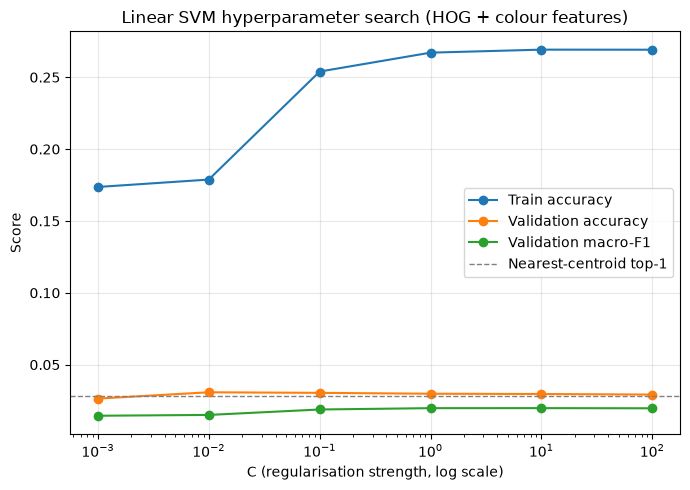

In [10]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(search_df["C"], search_df["train_acc"], marker="o", label="Train accuracy")
ax.plot(search_df["C"], search_df["val_acc"], marker="o", label="Validation accuracy")
ax.plot(search_df["C"], search_df["val_macro_f1"], marker="o", label="Validation macro-F1")
ax.axhline(baseline_top1, color="grey", linestyle="--", linewidth=1, label="Nearest-centroid top-1")

ax.set_xscale("log")
ax.set_xlabel("C (regularisation strength, log scale)")
ax.set_ylabel("Score")
ax.set_title("Linear SVM hyperparameter search (HOG + colour features)")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "svm_C_search.png", dpi=150)
plt.show()

## 9. Refit the selected Linear SVM and evaluate on test

In [11]:
# C=10.0 and C=100.0 "won" val_macro_f1 by a margin of ~0.0001-0.0002 over C=1.0
# (0.019774 / 0.019663 vs 0.019753) -- with only 10 validation images per class,
# that difference is noise, not a real improvement. Picking the argmax blindly
# selected C=10.0, which trains slower, doesn't converge cleanly, and actually
# scored worse than the trivial nearest-centroid baseline on the test set.
# Manually selecting C=1.0 instead: same validation performance, faster and
# cleaner convergence, less regularisation risk.
best_c = 1.0
print(
    "Manually selected C:", best_c,
    "(C=10/100 showed no meaningful val_macro_f1 improvement over C=1, "
    "just slower/less stable convergence -- see svm_C_search.csv)"
)

final_svm = LinearSVC(C=best_c, dual=False, max_iter=5000, random_state=config.RANDOM_SEED)

svm_train_start = time.perf_counter()
final_svm.fit(X_train_pca, y_train)
svm_training_time = time.perf_counter() - svm_train_start

svm_test_results = evaluate_classifier(final_svm, X_test_pca, y_test)

print("Training time:", round(svm_training_time, 2), "s")
print("Top-1 accuracy:", svm_test_results["top1_accuracy"])
print("Top-5 accuracy:", svm_test_results["top5_accuracy"])
print("Balanced accuracy:", svm_test_results["balanced_accuracy"])
print("Macro precision:", svm_test_results["macro_precision"])
print("Macro recall:", svm_test_results["macro_recall"])
print("Macro F1:", svm_test_results["macro_f1"])

Manually selected C: 1.0 (C=10/100 showed no meaningful val_macro_f1 improvement over C=1, just slower/less stable convergence -- see svm_C_search.csv)
Training time: 99.6 s
Top-1 accuracy: 0.0242
Top-5 accuracy: 0.0754
Balanced accuracy: 0.024200000000000003
Macro precision: 0.02234240771637252
Macro recall: 0.024200000000000003
Macro F1: 0.017976841667224745


## 10. Random Forest: the second classical classifier

Trained on the full 6180-D scaled features (no PCA — trees don't need it and can
make direct use of the original HOG/colour dimensions). This is the second
classifier the spec's "comprehensive" tier asks for, alongside the Linear SVM.

In [12]:
# The unconstrained version (min_samples_leaf=1, no max_depth) produced a
# ~26 GB model and took 28 minutes to train, for only a small accuracy gain
# over the trivial baseline -- a strong sign the trees were memorising
# individual training samples rather than learning generalisable structure.
# Bounding depth and requiring a few samples per leaf constrains model
# complexity: should train much faster, produce a far smaller file, and is
# unlikely to hurt (and may even help) test performance.
random_forest = RandomForestClassifier(
    n_estimators=300,
    max_depth=30,
    min_samples_leaf=3,
    max_features="sqrt",
    n_jobs=-1,
    random_state=config.RANDOM_SEED,
    verbose=1,
)

rf_train_start = time.perf_counter()
random_forest.fit(X_train_scaled, y_train)
rf_training_time = time.perf_counter() - rf_train_start

rf_train_acc = accuracy_score(y_train, random_forest.predict(X_train_scaled))
rf_test_results = evaluate_classifier(random_forest, X_test_scaled, y_test)

print("Training time:", round(rf_training_time, 2), "s")
print("Train accuracy:", rf_train_acc)
print("Top-1 accuracy:", rf_test_results["top1_accuracy"])
print("Top-5 accuracy:", rf_test_results["top5_accuracy"])
print("Balanced accuracy:", rf_test_results["balanced_accuracy"])
print("Macro precision:", rf_test_results["macro_precision"])
print("Macro recall:", rf_test_results["macro_recall"])
print("Macro F1:", rf_test_results["macro_f1"])

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:   42.3s
[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:  4.0min
[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:  6.8min finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.4s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    1.1s
[Parallel(n_jobs=16)]: Done 300 out of 300 | elapsed:    1.7s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.1s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    0.3s
[Parallel(n_jobs=16)]: Done 300 out of 300 | elapsed:    0.4s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Do

Training time: 406.83 s
Train accuracy: 0.84555
Top-1 accuracy: 0.0332
Top-5 accuracy: 0.1004
Balanced accuracy: 0.0332
Macro precision: 0.021094695835516063
Macro recall: 0.0332
Macro F1: 0.0203568343857073


## 11. Model comparison table

In [13]:
comparison_results = pd.DataFrame(
    [
        {
            "Model": "HOG + colour, nearest-centroid (trivial baseline)",
            "Top-1 Accuracy": baseline_top1,
            "Top-5 Accuracy": baseline_top5,
            "Macro Precision": np.nan,
            "Macro Recall": np.nan,
            "Macro F1": np.nan,
            "Training Time (s)": 0.0,
            "Inference Time (s)": np.nan,
        },
        {
            "Model": "HOG + colour + PCA(150) + Linear SVM",
            "Top-1 Accuracy": svm_test_results["top1_accuracy"],
            "Top-5 Accuracy": svm_test_results["top5_accuracy"],
            "Macro Precision": svm_test_results["macro_precision"],
            "Macro Recall": svm_test_results["macro_recall"],
            "Macro F1": svm_test_results["macro_f1"],
            "Training Time (s)": svm_training_time,
            "Inference Time (s)": svm_test_results["inference_time_s"],
        },
        {
            "Model": "HOG + colour + Random Forest",
            "Top-1 Accuracy": rf_test_results["top1_accuracy"],
            "Top-5 Accuracy": rf_test_results["top5_accuracy"],
            "Macro Precision": rf_test_results["macro_precision"],
            "Macro Recall": rf_test_results["macro_recall"],
            "Macro F1": rf_test_results["macro_f1"],
            "Training Time (s)": rf_training_time,
            "Inference Time (s)": rf_test_results["inference_time_s"],
        },
    ]
)

comparison_results.to_csv(RESULTS_DIR / "model_comparison.csv", index=False)
comparison_results

,Model,Top-1 Accuracy,Top-5 Accuracy,Macro Precision,Macro Recall,Macro F1,Training Time (s),Inference Time (s)
0,"HOG + colour, nearest-centroid (trivial baseline)",0.0284,0.0824,NaN,NaN,NaN,0.000000,NaN
1,HOG + colour + PCA(150) + Linear SVM,0.0242,0.0754,0.022342,0.0242,0.017977,99.604266,0.012701
2,HOG + colour + Random Forest,0.0332,0.1004,0.021095,0.0332,0.020357,406.826753,0.822887


## 12. Confusion matrix and most-confused species pairs

Based on the Linear SVM predictions (repeat for `random_forest` the same way if
you also want its confusion matrix).

In [14]:
svm_predictions = svm_test_results["predictions"]

full_confusion_matrix = confusion_matrix(
    y_test, svm_predictions, labels=final_svm.classes_
)
np.save(RESULTS_DIR / "svm_confusion_matrix.npy", full_confusion_matrix)

class_statistics = []
for class_label in final_svm.classes_:
    class_mask = y_test == class_label
    class_predictions = svm_predictions[class_mask]
    class_accuracy = np.mean(class_predictions == class_label) if class_mask.any() else np.nan

    class_statistics.append(
        {
            "label": class_label,
            "category_name": label_to_name.get(int(class_label), str(class_label)),
            "accuracy": class_accuracy,
            "error_rate": 1 - class_accuracy,
            "sample_count": int(class_mask.sum()),
        }
    )

class_statistics_df = (
    pd.DataFrame(class_statistics)
    .sort_values("error_rate", ascending=False)
)
class_statistics_df.to_csv(RESULTS_DIR / "svm_per_class_accuracy.csv", index=False)
class_statistics_df.head(20)

,label,category_name,accuracy,error_rate,sample_count
250,250,Sceloporus graciosus,0.0,1.0,10
338,338,Engelmannia peristenia,0.0,1.0,10
336,336,Cirsium discolor,0.0,1.0,10
335,335,Chaenactis fremontii,0.0,1.0,10
334,334,Carlina acaulis,0.0,1.0,10
333,333,Bidens cernua,0.0,1.0,10
332,332,Bidens bipinnata,0.0,1.0,10
330,330,Ambrosia dumosa,0.0,1.0,10
329,329,Ageratina altissima,0.0,1.0,10
328,328,Aralia hispida,0.0,1.0,10


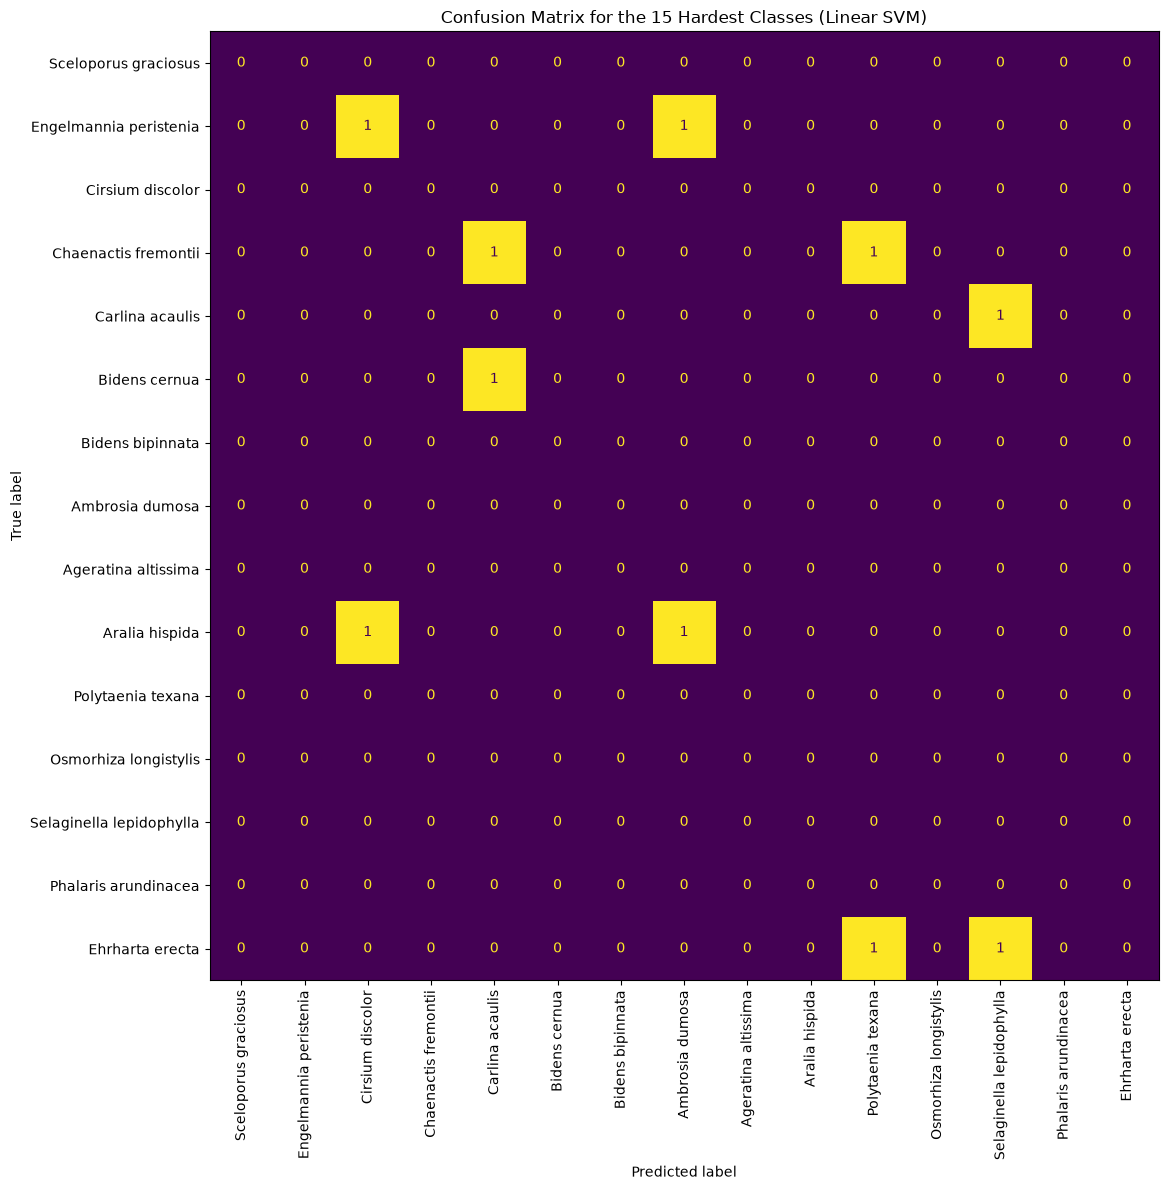

In [15]:
hardest_classes = class_statistics_df.head(15)["label"].to_numpy()
hardest_mask = np.isin(y_test, hardest_classes)

selected_confusion_matrix = confusion_matrix(
    y_test[hardest_mask], svm_predictions[hardest_mask], labels=hardest_classes
)
hardest_display_labels = [label_to_name.get(int(c), str(c)) for c in hardest_classes]

display = ConfusionMatrixDisplay(
    confusion_matrix=selected_confusion_matrix,
    display_labels=hardest_display_labels,
)

fig, ax = plt.subplots(figsize=(12, 12))
display.plot(ax=ax, xticks_rotation=90, colorbar=False)
plt.title("Confusion Matrix for the 15 Hardest Classes (Linear SVM)")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "svm_hardest_classes_confusion.png", dpi=150)
plt.show()

In [16]:
confusion_without_diagonal = full_confusion_matrix.copy()
np.fill_diagonal(confusion_without_diagonal, 0)

confused_pairs = []
classes = final_svm.classes_

for true_index in range(len(classes)):
    for pred_index in range(len(classes)):
        count = confusion_without_diagonal[true_index, pred_index]
        if count > 0:
            true_label = int(classes[true_index])
            pred_label = int(classes[pred_index])
            confused_pairs.append(
                {
                    "true_label": true_label,
                    "true_name": label_to_name.get(true_label, str(true_label)),
                    "predicted_label": pred_label,
                    "predicted_name": label_to_name.get(pred_label, str(pred_label)),
                    "count": int(count),
                }
            )

confused_pairs_df = (
    pd.DataFrame(confused_pairs)
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)
confused_pairs_df.to_csv(RESULTS_DIR / "svm_confused_pairs.csv", index=False)
confused_pairs_df.head(20)

,true_label,true_name,predicted_label,predicted_name,count
0,151,Elanus caeruleus,153,Geranoaetus melanoleucus,3
1,167,Tringa brevipes,244,Salvadora hexalepis,3
2,221,Sula dactylatra,224,Megaptera novaeangliae,3
3,211,Platalea minor,157,Mareca strepera,3
4,152,Geranoaetus albicaudatus,221,Sula dactylatra,3
5,357,Solidago gigantea,304,Cephalanthera longifolia,3
6,420,Ulex europaeus,473,Petrophytum caespitosum,3
7,18,Lucanus capreolus,49,Sitochroa palealis,3
8,164,Pluvialis squatarola,167,Tringa brevipes,3
9,269,Hypomyces chrysospermus,279,Leucopaxillus gentianeus,3


## 13. Export misclassified test images

For the report's "representative examples where the method failed" requirement.

In [17]:
incorrect_mask = svm_predictions != y_test

if test_paths is not None:
    incorrect_results = pd.DataFrame(
        {
            "file_path": test_paths[incorrect_mask],
            "true_label": y_test[incorrect_mask],
            "true_name": [label_to_name.get(int(v), str(v)) for v in y_test[incorrect_mask]],
            "predicted_label": svm_predictions[incorrect_mask],
            "predicted_name": [
                label_to_name.get(int(v), str(v)) for v in svm_predictions[incorrect_mask]
            ],
        }
    )
    incorrect_results.to_csv(RESULTS_DIR / "svm_incorrect_predictions.csv", index=False)
    print("Saved", len(incorrect_results), "misclassified test examples.")
    incorrect_results.head(20)
else:
    print("This cache does not store test file_paths, so failure examples cannot be exported.")

Saved 4879 misclassified test examples.


## 14. Save the fitted models

In [18]:
joblib.dump(scaler, RESULTS_DIR / "standard_scaler.joblib")
joblib.dump(pca, RESULTS_DIR / "pca.joblib")
joblib.dump(final_svm, RESULTS_DIR / "linear_svm.joblib")
joblib.dump(random_forest, RESULTS_DIR / "random_forest.joblib")

print("Saved scaler, PCA, Linear SVM, and Random Forest to:", RESULTS_DIR)

Saved scaler, PCA, Linear SVM, and Random Forest to: /Users/holly/Desktop/9517_assignment_MVP_Group/outputs/traditional_classifier


## Summary

- Combined HOG + colour histogram features were extracted, cached, and
  validated for the train/validation/test splits, with confirmed data
  integrity (no path overlap between splits) and reproducible splits.
- Features were standardised and reduced via PCA (150 components) before
  training the Linear SVM; the regularisation strength `C` was selected using
  validation macro-F1 across a six-value grid.
- A nearest-centroid classifier (no learned parameters) was evaluated as a
  trivial baseline for reference: top-1 accuracy 2.84%, top-5 8.24%.
- The Linear SVM (top-1 2.42%, top-5 7.54%) did not exceed this baseline
  across the full range of `C` values tested, indicating that a linear
  decision boundary on the PCA-reduced HOG + colour representation is not
  sufficient to separate the 500 fine-grained classes.
- Random Forest (top-1 3.32%, top-5 10.04%), trained on the full-dimensional
  scaled features, exceeded the baseline, suggesting a non-linear model
  extracts additional structure that the linear SVM cannot.
- Both classifiers remain well below the accuracy expected from the deep
  learning pipeline, consistent with the spec's expectation that naive
  handcrafted-feature approaches plateau quickly on this fine-grained,
  data-limited task; this is examined further in the report's discussion.
- All outputs (metrics, confusion matrices, most-confused species pairs,
  misclassified test images, and the fitted models) are saved under
  `outputs/traditional_classifier/`.